# Magnetic flux loops PCA notebook

Notebook demonstrating performing principal component analysis on magnetic flux loop data.

Get all shot numbers

In [1]:
import fsspec

local_path = f"/rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp/level2/"
fs = fsspec.filesystem('file')

# List all files and folders in the base path
all_files = fs.ls(local_path)

# Extract shot_id from the filenames
shot_ids = [file.split('/')[-1].replace('.zarr', '') for file in all_files]

# Convert them to integers
shot_ids = [int(shot_id) for shot_id in shot_ids if shot_id.isdigit()]

print(len(shot_ids))

11573


Define some utility functions

In [2]:
import xarray as xr
import zarr

def get_shot_fsstore(shot_id):
  local_path = f"/rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp/level2/{shot_id}.zarr"
  fs = fsspec.filesystem('file')

  store = zarr.storage.FSStore(fs=fs, url=local_path, check=False)

  return store


def get_flux_loop(shot_id):
  store = get_shot_fsstore(shot_id)
  profiles = xr.open_zarr(store, group="magnetics")
  flux_loop = profiles["flux_loop_flux"]
  return flux_loop

Iterate over some random shot IDs and plot flux loop profiles

  0%|          | 0/10 [00:00<?, ?it/s]

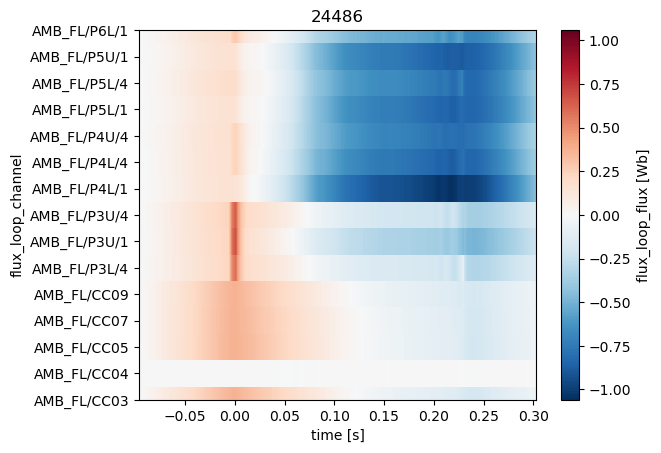

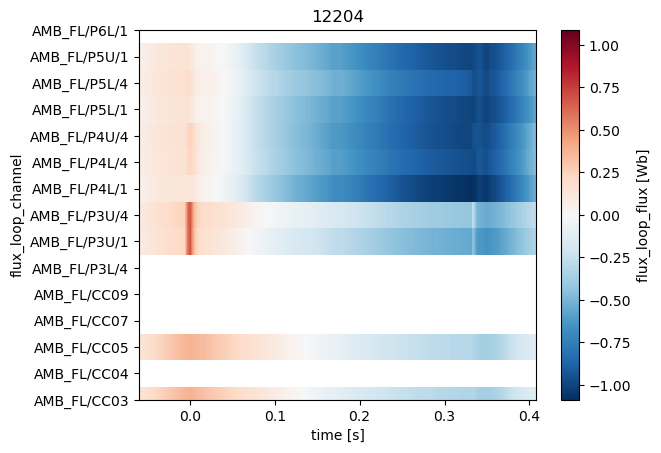

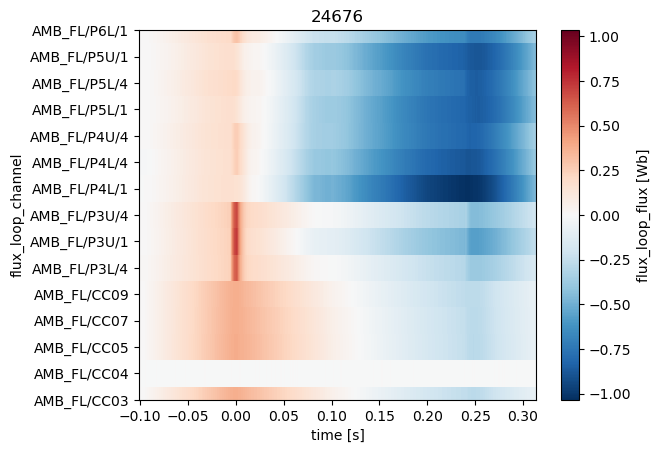

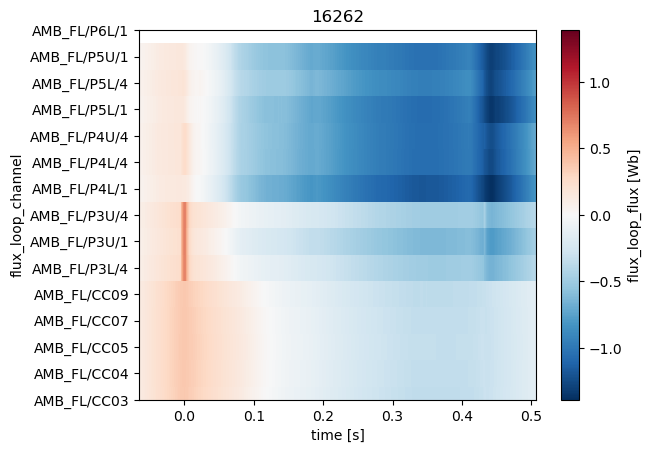

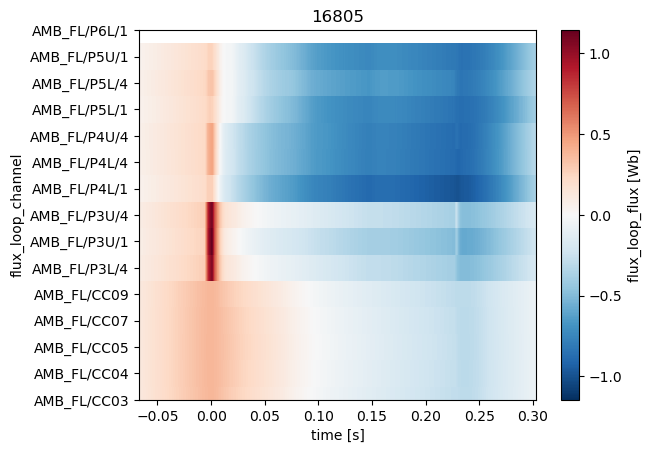

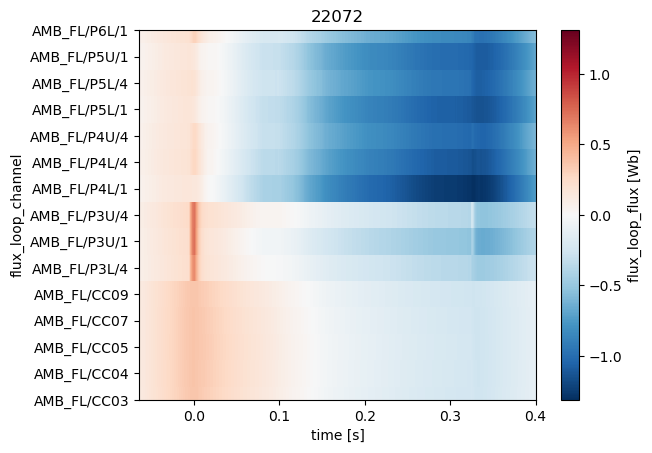

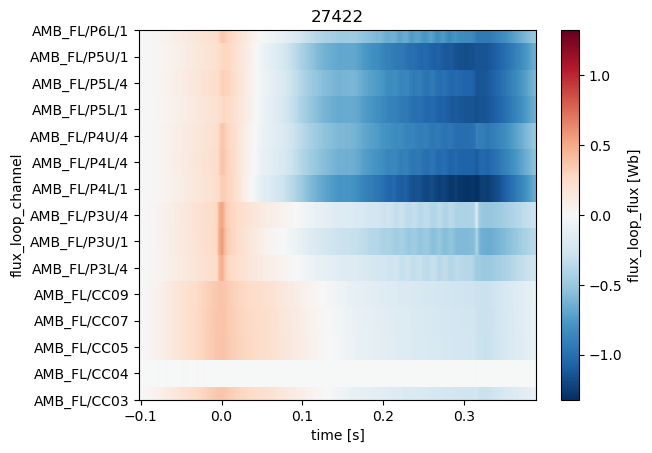

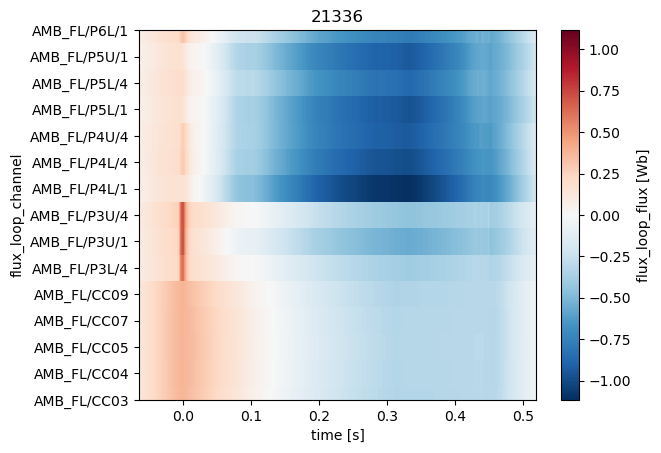

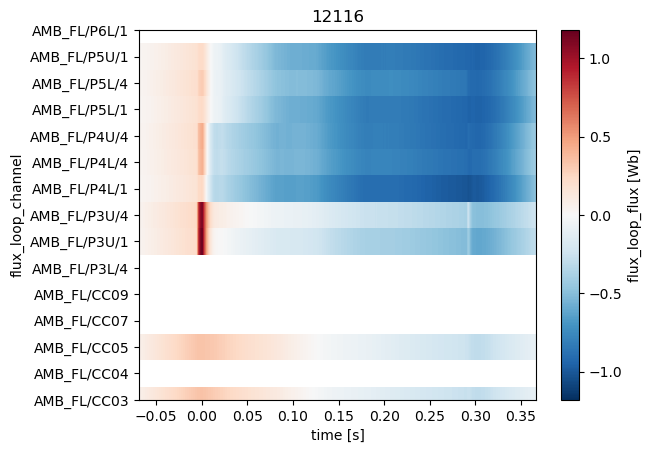

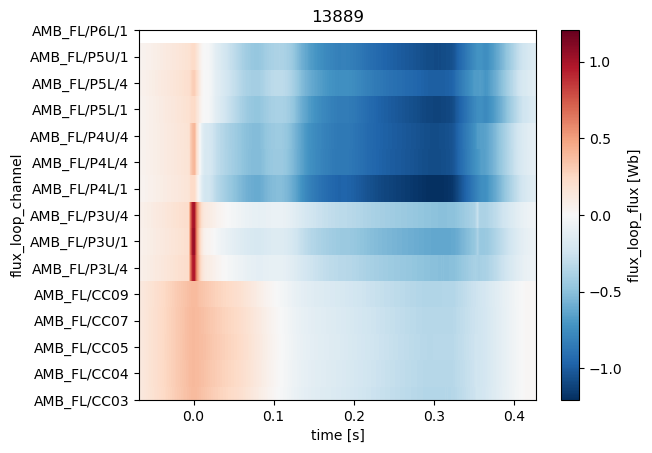

In [3]:
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm

random.seed(42)
random.shuffle(shot_ids)
random_shot_ids = shot_ids[:10]

for shot_id in tqdm(random_shot_ids):
    flux_loop = get_flux_loop(shot_id)
    fig, ax = plt.subplots()
    flux_loop.plot(ax=ax)
    ax.set_title(shot_id)

Inspect an interesting shot

[ 0.08429731  0.08531547  0.08633363 ... -0.2313752  -0.23035705
 -0.23035705]
[nan nan nan ... nan nan nan]


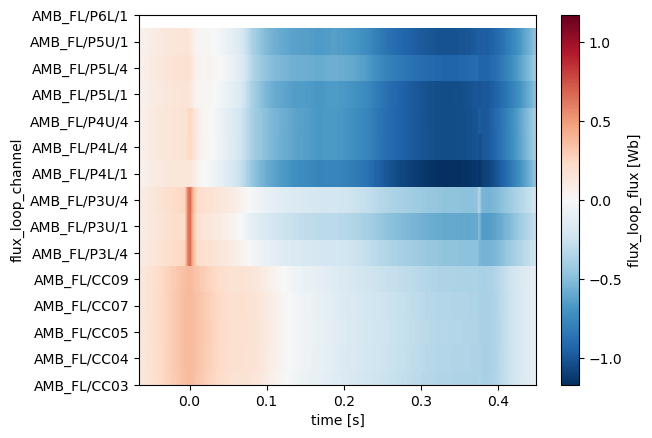

In [4]:
flux_loop = get_flux_loop(16092)

fig, ax = plt.subplots()
flux_loop.plot(ax=ax)
print(flux_loop.sel(flux_loop_channel="AMB_FL/P3L/4").values)
print(flux_loop.sel(flux_loop_channel="AMB_FL/P6L/1").values)

PCA does not work with NaN values, so these must be imputed. Demonstrated here is imputation of NaN flux loop channel values as the mean across non-NaN channel values at the same time index.

Text(0.5, 1.0, 'Imputed')

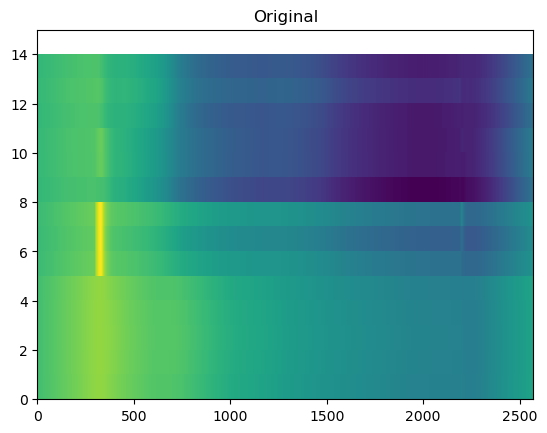

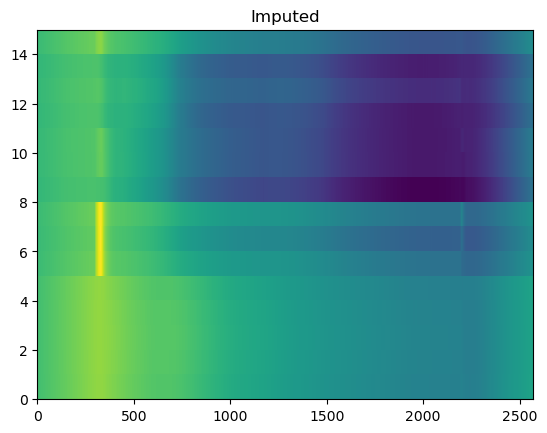

In [5]:
from sklearn.impute import SimpleImputer
import numpy as np

fig, ax = plt.subplots()
ax.pcolorfast(flux_loop.values)
ax.set_title("Original")

imp = SimpleImputer(missing_values=np.nan, strategy="mean")
vals = flux_loop.values
imp.fit(vals)
vals = imp.transform(vals)

fig, ax = plt.subplots()
ax.pcolorfast(vals)
ax.set_title("Imputed")

Get an array of flux loops across all shots. Perform imputation as above.

In [ ]:
from multiprocessing import Pool

def process_shot_id(shot_id):
    """
    Process a single shot ID to get flux loop values, handle missing data, 
    and return the imputed array.

    Args:
        shot_id: The ID of the shot to process.

    Returns:
        Imputed numpy array of flux loop values for the given shot ID.
    """
    try:
        flux_loop = get_flux_loop(shot_id)
        vals = flux_loop.values
        
        imp = SimpleImputer(missing_values=np.nan, strategy="mean")
        imp.fit(vals)
        vals = imp.transform(vals)
        
        return vals
    except Exception as e:
        print(f"Error processing shot ID {shot_id}: {e}")
        return None


# Open magnetics profile for the first shot to initialize flux_loop_array
store = get_shot_fsstore(shot_ids[0])
profiles = xr.open_zarr(store, group="magnetics")
flux_loop_array = profiles["flux_loop_flux"].values

# Process each shot ID in parallel, excluding the first one which we already processed
with Pool(processes=4) as pool:
    results = list(tqdm(
        pool.imap(process_shot_id, shot_ids[1:]),
        total=len(shot_ids[1:])
    ))

# Drop results where getting flux loop has failed
valid_results = [vals for vals in results if vals is not None]

# Concatenate the results
concatenated_array = np.concatenate(valid_results, axis=1)
flux_loop_array = np.concatenate((flux_loop_array, concatenated_array), axis=1)

flux_loop_array = flux_loop_array.T

  0%|          | 0/11572 [00:00<?, ?it/s]

Error processing shot ID 23766: "No variable named 'flux_loop_flux'. Variables on the dataset include ['b_field_pol_probe_cc_channel', 'b_field_pol_probe_cc_field', 'b_field_pol_probe_omv_channel', 'b_field_pol_probe_omv_voltage', 'b_field_tor_probe_cc_channel', ..., 'b_field_tor_probe_saddle_voltage_channel', 'ip', 'time', 'time_mirnov', 'time_saddle']"
Error processing shot ID 20154: "No variable named 'flux_loop_flux'. Variables on the dataset include ['ip', 'time']"
Error processing shot ID 20148: "No variable named 'flux_loop_flux'. Variables on the dataset include ['ip', 'time']"
Error processing shot ID 20149: "No variable named 'flux_loop_flux'. Variables on the dataset include ['ip', 'time']"
Error processing shot ID 20156: "No variable named 'flux_loop_flux'. Variables on the dataset include ['ip', 'time']"
Error processing shot ID 21037: "No variable named 'flux_loop_flux'. Variables on the dataset include ['b_field_pol_probe_cc_channel', 'b_field_pol_probe_cc_field', 'b_fie

KeyboardInterrupt: 

Principal component analysis

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
pca.fit(flux_loop_array)

explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = 0

for i, val in enumerate(explained_variance):
    cumulative_explained_variance += val
    print(f"Principal component: {i+1}")
    print(f"Explained variance: {val:.3f}")
    print(f"Cumulative explained variance: {cumulative_explained_variance:.3f}\n")

Principal component: 1
Explained variance: 0.935
Cumulative explained variance: 0.935

Principal component: 2
Explained variance: 0.040
Cumulative explained variance: 0.975

Principal component: 3
Explained variance: 0.007
Cumulative explained variance: 0.982

Principal component: 4
Explained variance: 0.006
Cumulative explained variance: 0.989

Principal component: 5
Explained variance: 0.004
Cumulative explained variance: 0.993



Demonstrate PCA transform and reconstruction

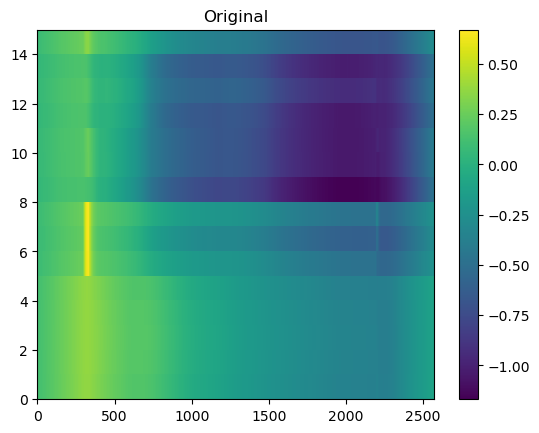

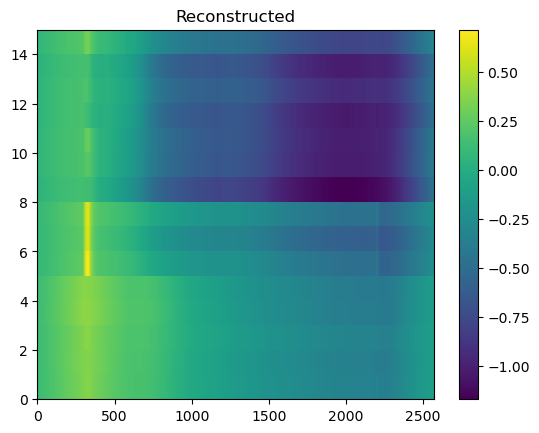

In [25]:
flux_loop = get_flux_loop(16092)
vals = flux_loop.values

imp = SimpleImputer(missing_values=np.nan, strategy="mean")
imp.fit(vals)
vals = imp.transform(vals)

transformed = pca.transform(vals.T)
reconstructed = pca.inverse_transform(transformed).T

fig, ax = plt.subplots()
ax.set_title("Original")
p = ax.pcolorfast(vals)
fig.colorbar(p, ax=ax)

fig, ax = plt.subplots()
ax.set_title("Reconstructed")
p = ax.pcolorfast(reconstructed)
fig.colorbar(p, ax=ax)